# 2주차 

## 금주 목표
* 오차역전파(Backpropagation)와 경사하강법의 원리 이해
    * 손실 함수(Loss Function)가 줄어드는 원리 이해
    * 손실함수와 감소의 과정을 그래프로 시각화하여 정리
* 자동 미분을 활용한 선형 회귀 구현
    * 라이브러리 없이 파이썬 코드만으로 경사하강법 수식을 직접 구현

# 1. 경사하강법

**손실함수** : 신경망의 성능의 나쁨을 나타내는 지표  

**경사하강법** : 손실함수의 성능을 낮추는 방법으로 손실함수를 편미분한 값이 편미분한 변수에 대해 얼만큼 영향을 받는지를 보고 손실이 줄어드는 방향으로 나아가는 것  

선형 회귀로 진행  
통상적으로 선형회귀에서는 평균제곱 오차 사용  
$$ loss = \frac{1}{m} \sum_{i=1}^m (H(x_i) - y_i)^2) $$

# 2. 오차역전파

각 변수(가중치, 편향 등)에 대해 편미분하는 방식(수치미분)은 신경망의 층이 쌓일 수록 계싼량이 폭발적으로 많아짐  
이에 대한 해결 방법으로 미적분학의 Chain Rule을 활용하여 최종 손실값에 대한 미분을 합성함수를 구성하는 각 함수의 미분의 곱으로 분리해 낼 수 있음  

**계산 그래프** :계산 과정을 표현한 그래프  
복수의 노드와 에자로 표현  

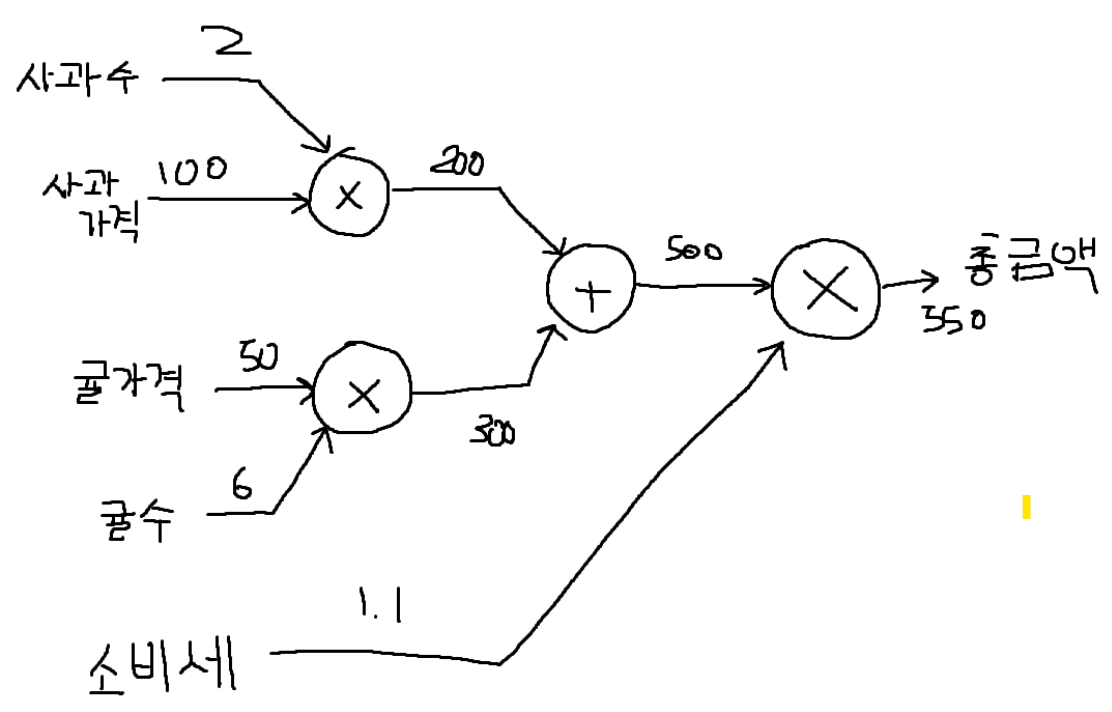

사과, 귤을 살때 소비세를 포함한 총 구매 가격 구매하는 상황을 표현시 위와 같은 계싼 그래프로 나타 낼 수 있음  
화살표가 향하는 방향을 순전파라 할 때, 역전파는 순전파의 반대방향으로 향함  


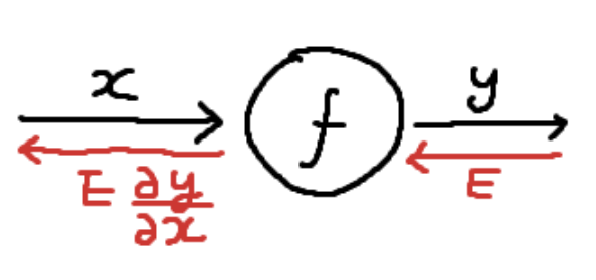

위 그림처럼 신호 E에 대해 x가 얼마만큼의 영향을 미쳤는지를 구할 수 있음  
사전에 x와 y의 관계를 총하여 $\frac{\partial y}{\partial x} $를 미리 파악해두면 직접 미분 하지 않고서도 구할 수 있기에 앞서 언급한 문제(미분 속도 느림)를 해결 할 수 있음

**+노드**  
식 : $z = x + y$을 대상으로 역전파  
$ \frac{\partial z}{\partial x} = 1$  
$ \frac{\partial z}{\partial y} = 1$    
이 때 상류에서 전해진 미분을 $\frac{\partial L}{\partial z}$ 라하면 결과적으로는  
x의 에자는 $\frac{\partial L}{\partial z} * 1$  
y의 에자는 $\frac{\partial L}{\partial z} * 1$  
따라서 상류의 값 여과 없이 흘려보냄  

In [ ]:
class AddLayer:
    def __init__(self):
        pass

    def forward(self,x,y):
        out = x+y
        return out

    def backward(self, dout):
        dx = dout * 1
        dy = dout * 1
        return dx,dy

***노드**  
식 : $z = x * y$을 대상으로 역전파  
$\frac{\partial z}{\partial x} = y$  
$\frac{\partial z}{\partial y} = x$  
이 때 상류에서 전해진 미분을 $\frac{\partial L}{\partial z}$ 라하면 결과적으로는  
x의 에자는 $\frac{\partial L}{\partial z} * y$  
y의 에자는 $\frac{\partial L}{\partial z} * x$  
즉 둘을 바꾼 값을 각각 하류로 흘려보냄  

In [ ]:
class MulLayer:
    def __init__(self):
        self.x = None
        self.y = None

    def forward(self,x,y):
        self.x = x
        self.y = y
        out = x*y

        return out

    def backward(self, dout):
        dx = dout * self.y # 미분 직적 수행잉 아닌 이미 계산된 식 사용
        dy = dout * self.x

        return dx,dy

**/노드**  
식 : $ y = \frac{1}{x} $을 대상으로 역전파
$ \frac{\partial y}{\partial x} = -\frac{1}{x^2} = -y^2$  
따라서 역전파에서 흘러온 값에 순전파의 출력을 제곱한 값에 - 붙여 하류로 흘려 보냄  

**exp노드**  
식 : $y=e^x$을 대상으로 역전파  
$ \frac{\partial y}{\partial x} = e^x$  
따라서 상류의 값에 그냥 $e^x$ 곱해서 하류로 흘려보냄  


In [ ]:
class Sigmoid:
    def __init__(self):
        self.out - None

    def forward(self,x):
        out = 1 / (1+np.exp(-x))
        self.out = out

        return out

    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out

        return dx

# 3. 자동미분을 활용한 선형회귀